# Análise da etapa 12.4 do trabalho

Este notebook analisa o arquivo `outputs/tables/estimativas_brutas.csv` para resumir as etapas de estimação, inferência e testes do item 12.4.

Limitação importante: este CSV contém as estimativas por repetição, mas não contém os dados brutos de cada amostra nem os resíduos. Por isso, a parte de diagnóstico e correção só pode ser feita de forma indireta, usando figuras já geradas em `outputs/figures` ou rerodando a simulação a partir do código do projeto.

## Objetivo

Responder aos itens do enunciado:

- média dos estimadores
- viés
- variância
- erro quadrático médio
- cobertura dos intervalos de confiança
- taxa de rejeição sob $H_0$
- poder do teste

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)
sns.set_theme(style='whitegrid')

root = Path.cwd().resolve()
if root.name == 'notebooks':
    project_root = root.parent
else:
    project_root = root

csv_path = project_root / 'outputs' / 'tables' / 'estimativas_brutas.csv'
df = pd.read_csv(csv_path)
df.head()

,beta0_hat,beta1_hat,ci_beta0_low,ci_beta0_high,ci_beta1_low,ci_beta1_high,pvalue_beta1,scenario,scenario_label,n,model
0,0.370232,1.765811,0.014136,0.726328,1.410864,2.120757,6.334469e-11,ar1_errors,C5_erros_correlacionados_ar1,30,original_scale
1,1.367582,1.663282,1.106135,1.629029,1.430989,1.895575,1.142237e-14,ar1_errors,C5_erros_correlacionados_ar1,30,original_scale
2,0.859468,1.999416,0.536519,1.182418,1.717691,2.281142,1.424060e-14,ar1_errors,C5_erros_correlacionados_ar1,30,original_scale
3,1.029890,1.704807,0.710991,1.348788,1.449639,1.959976,6.314130e-14,ar1_errors,C5_erros_correlacionados_ar1,30,original_scale
4,1.369651,2.132027,1.093168,1.646134,1.876802,2.387252,2.321982e-16,ar1_errors,C5_erros_correlacionados_ar1,30,original_scale


## Estrutura do arquivo

Cada linha representa uma repetição da simulação. As colunas disponíveis são:

- `beta0_hat`, `beta1_hat`
- limites inferior e superior dos intervalos de confiança
- `pvalue_beta1`
- `scenario`, `scenario_label`, `n`, `model`

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   beta0_hat       16000 non-null  float64
 1   beta1_hat       16000 non-null  float64
 2   ci_beta0_low    16000 non-null  float64
 3   ci_beta0_high   16000 non-null  float64
 4   ci_beta1_low    16000 non-null  float64
 5   ci_beta1_high   16000 non-null  float64
 6   pvalue_beta1    16000 non-null  float64
 7   scenario        16000 non-null  object 
 8   scenario_label  16000 non-null  object 
 9   n               16000 non-null  int64  
 10  model           16000 non-null  object 
dtypes: float64(7), int64(1), object(3)
memory usage: 1.3+ MB


## Parâmetros de referência

Os valores verdadeiros usados no projeto são os definidos em `src/config.py`: $Beta_0 = 1$, $Beta_1 = 2$ e $Alpha = 0.05$.

In [3]:
true_beta0 = 1.0
true_beta1 = 2.0
alpha = 0.05

df['reject_h0'] = df['pvalue_beta1'] < alpha
df['cover_beta0'] = (df['ci_beta0_low'] <= true_beta0) & (true_beta0 <= df['ci_beta0_high'])
df['cover_beta1'] = (df['ci_beta1_low'] <= true_beta1) & (true_beta1 <= df['ci_beta1_high'])
df.head()

,beta0_hat,beta1_hat,ci_beta0_low,ci_beta0_high,ci_beta1_low,ci_beta1_high,pvalue_beta1,scenario,scenario_label,n,model,reject_h0,cover_beta0,cover_beta1
0,0.370232,1.765811,0.014136,0.726328,1.410864,2.120757,6.334469e-11,ar1_errors,C5_erros_correlacionados_ar1,30,original_scale,True,False,True
1,1.367582,1.663282,1.106135,1.629029,1.430989,1.895575,1.142237e-14,ar1_errors,C5_erros_correlacionados_ar1,30,original_scale,True,False,False
2,0.859468,1.999416,0.536519,1.182418,1.717691,2.281142,1.424060e-14,ar1_errors,C5_erros_correlacionados_ar1,30,original_scale,True,True,True
3,1.029890,1.704807,0.710991,1.348788,1.449639,1.959976,6.314130e-14,ar1_errors,C5_erros_correlacionados_ar1,30,original_scale,True,True,False
4,1.369651,2.132027,1.093168,1.646134,1.876802,2.387252,2.321982e-16,ar1_errors,C5_erros_correlacionados_ar1,30,original_scale,True,False,True


## Funções auxiliares

A seguir, uma função para resumir cada combinação de cenário, tamanho amostral, modelo e parâmetro.

In [4]:
def summarize_group(group: pd.DataFrame, parameter: str, true_value: float) -> dict:
    estimates = group[f'{parameter}_hat']
    ci_low = group[f'ci_{parameter}_low']
    ci_high = group[f'ci_{parameter}_high']
    mean_hat = estimates.mean()
    bias = mean_hat - true_value
    variance = estimates.var(ddof=1)
    mse = np.mean((estimates - true_value) ** 2)
    coverage = ((ci_low <= true_value) & (true_value <= ci_high)).mean()
    return {
        'mean_hat': mean_hat,
        'bias': bias,
        'variance': variance,
        'mse': mse,
        'coverage': coverage,
    }

def build_summary_table(data: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (scenario, scenario_label, n, model), group in data.groupby(['scenario', 'scenario_label', 'n', 'model'], sort=True):
        common = {
            'scenario': scenario,
            'scenario_label': scenario_label,
            'n': n,
            'model': model,
            'replications': len(group),
            'size_h0': group['reject_h0'].mean(),
            'power_h1': group['reject_h0'].mean(),
        }
        for parameter, true_value in [('beta0', true_beta0), ('beta1', true_beta1)]:
            stats = summarize_group(group, parameter, true_value)
            rows.append({
                **common,
                'parameter': parameter,
                **stats,
            })
    return pd.DataFrame(rows)

summary = build_summary_table(df)
summary.sort_values(['scenario', 'n', 'model', 'parameter']).head(12)

,scenario,scenario_label,n,model,replications,size_h0,power_h1,parameter,mean_hat,bias,variance,mse,coverage
0,ar1_errors,C5_erros_correlacionados_ar1,30,original_scale,1000,1.0,1.0,beta0,0.996576,-0.003424,0.174261,0.174098,0.561
1,ar1_errors,C5_erros_correlacionados_ar1,30,original_scale,1000,1.0,1.0,beta1,2.000569,0.000569,0.023720,0.023697,0.940
2,ar1_errors,C5_erros_correlacionados_ar1,100,original_scale,1000,1.0,1.0,beta0,0.992164,-0.007836,0.056076,0.056081,0.594
3,ar1_errors,C5_erros_correlacionados_ar1,100,original_scale,1000,1.0,1.0,beta1,1.999251,-0.000749,0.007394,0.007387,0.958
4,classic_normal,C1_classico_normal,30,original_scale,1000,1.0,1.0,beta0,0.998163,-0.001837,0.035229,0.035198,0.948
5,classic_normal,C1_classico_normal,30,original_scale,1000,1.0,1.0,beta1,2.004187,0.004187,0.026348,0.026339,0.954
6,classic_normal,C1_classico_normal,100,original_scale,1000,1.0,1.0,beta0,1.003529,0.003529,0.009418,0.009421,0.953
7,classic_normal,C1_classico_normal,100,original_scale,1000,1.0,1.0,beta1,1.996901,-0.003099,0.007404,0.007406,0.951
8,exponential_lognormal,C6_relacao_exponencial_lognormal,30,log_transform,1000,1.0,1.0,beta0,0.997836,-0.002164,0.005569,0.005568,0.945
9,exponential_lognormal,C6_relacao_exponencial_lognormal,30,log_transform,1000,1.0,1.0,beta1,2.000425,0.000425,0.004226,0.004222,0.947


## Observação técnica sobre H0 e poder

O CSV traz uma única coluna de p-value para o teste de $Beta_1$. No código do projeto, o poder e a taxa de rejeição são calculados a partir de duas corridas: uma sob $H_0$ e outra sob $H_1$.

Como o CSV anexado já consolida as estimativas, a forma mais segura aqui é usar a taxa de rejeição observada em cada grupo como indicador de decisão do teste. Em cenários sob $H_1$, essa taxa corresponde ao poder empírico; em cenários sob $H_0$, corresponde ao nível empírico do teste.

In [5]:
summary_table = summary[['scenario_label', 'scenario', 'n', 'model', 'parameter', 'mean_hat', 'bias', 'variance', 'mse', 'coverage', 'size_h0', 'power_h1']]
summary_table.sort_values(['scenario', 'n', 'model', 'parameter']).reset_index(drop=True)

,scenario_label,scenario,n,model,parameter,mean_hat,bias,variance,mse,coverage,size_h0,power_h1
0,C5_erros_correlacionados_ar1,ar1_errors,30,original_scale,beta0,0.996576,-0.003424,0.174261,0.174098,0.561,1.0,1.0
1,C5_erros_correlacionados_ar1,ar1_errors,30,original_scale,beta1,2.000569,0.000569,0.023720,0.023697,0.940,1.0,1.0
2,C5_erros_correlacionados_ar1,ar1_errors,100,original_scale,beta0,0.992164,-0.007836,0.056076,0.056081,0.594,1.0,1.0
3,C5_erros_correlacionados_ar1,ar1_errors,100,original_scale,beta1,1.999251,-0.000749,0.007394,0.007387,0.958,1.0,1.0
4,C1_classico_normal,classic_normal,30,original_scale,beta0,0.998163,-0.001837,0.035229,0.035198,0.948,1.0,1.0
5,C1_classico_normal,classic_normal,30,original_scale,beta1,2.004187,0.004187,0.026348,0.026339,0.954,1.0,1.0
6,C1_classico_normal,classic_normal,100,original_scale,beta0,1.003529,0.003529,0.009418,0.009421,0.953,1.0,1.0
7,C1_classico_normal,classic_normal,100,original_scale,beta1,1.996901,-0.003099,0.007404,0.007406,0.951,1.0,1.0
8,C6_relacao_exponencial_lognormal,exponential_lognormal,30,log_transform,beta0,0.997836,-0.002164,0.005569,0.005568,0.945,1.0,1.0
9,C6_relacao_exponencial_lognormal,exponential_lognormal,30,log_transform,beta1,2.000425,0.000425,0.004226,0.004222,0.947,1.0,1.0


## Estimação

Aqui você interpreta a média dos estimadores, o viés, a variância e o EQM por cenário, tamanho amostral e modelo.

Em geral, o padrão esperado é:

- cenário clássico: menor viés e maior aderência ao valor verdadeiro
- caudas pesadas e assimetria: maior dispersão e possível aumento no EQM
- erro com média não nula constante: impacto mais forte no intercepto do que em $Beta_1$
- erro dependente de X: viés também em $Beta_1$
- caso exponencial: ajuste na escala log tende a melhorar o comportamento do modelo

In [6]:
estimation_focus = summary_table[['scenario_label', 'n', 'model', 'parameter', 'mean_hat', 'bias', 'variance', 'mse']].copy()
estimation_focus.sort_values(['scenario_label', 'n', 'model', 'parameter']).reset_index(drop=True)

,scenario_label,n,model,parameter,mean_hat,bias,variance,mse
0,C1_classico_normal,30,original_scale,beta0,0.998163,-0.001837,0.035229,0.035198
1,C1_classico_normal,30,original_scale,beta1,2.004187,0.004187,0.026348,0.026339
2,C1_classico_normal,100,original_scale,beta0,1.003529,0.003529,0.009418,0.009421
3,C1_classico_normal,100,original_scale,beta1,1.996901,-0.003099,0.007404,0.007406
4,C2_caudas_pesadas,30,original_scale,beta0,1.004936,0.004936,0.033249,0.033240
5,C2_caudas_pesadas,30,original_scale,beta1,1.998979,-0.001021,0.025827,0.025802
6,C2_caudas_pesadas,100,original_scale,beta0,1.001622,0.001622,0.009892,0.009884
7,C2_caudas_pesadas,100,original_scale,beta1,2.002533,0.002533,0.007841,0.007839
8,C3_erros_assimetricos,30,original_scale,beta0,1.006193,0.006193,0.034088,0.034093
9,C3_erros_assimetricos,30,original_scale,beta1,2.003529,0.003529,0.027039,0.027025


## Inferência

A cobertura é calculada como a proporção de intervalos que contêm o valor verdadeiro. Para MRLS, espera-se cobertura próxima de $1 - lpha = 0.95$ no cenário clássico, com possível deterioração nos cenários com violações mais fortes das hipóteses.

In [7]:
inference_focus = summary_table[['scenario_label', 'n', 'model', 'parameter', 'coverage']].copy()
inference_focus.sort_values(['scenario_label', 'n', 'model', 'parameter']).reset_index(drop=True)

,scenario_label,n,model,parameter,coverage
0,C1_classico_normal,30,original_scale,beta0,0.948
1,C1_classico_normal,30,original_scale,beta1,0.954
2,C1_classico_normal,100,original_scale,beta0,0.953
3,C1_classico_normal,100,original_scale,beta1,0.951
4,C2_caudas_pesadas,30,original_scale,beta0,0.952
5,C2_caudas_pesadas,30,original_scale,beta1,0.973
6,C2_caudas_pesadas,100,original_scale,beta0,0.947
7,C2_caudas_pesadas,100,original_scale,beta1,0.939
8,C3_erros_assimetricos,30,original_scale,beta0,0.938
9,C3_erros_assimetricos,30,original_scale,beta1,0.950


## Testes

Como o arquivo contém apenas uma corrida consolidada por combinação, usamos a proporção de rejeição observada com base nos p-values de `beta1`.

Se você quiser uma análise mais fiel de poder sob $H_1$ e tamanho sob $H_0$, o ideal é rerodar o pipeline do projeto em `src/simulation.py`, porque ele separa explicitamente as duas condições.

In [8]:
test_focus = summary_table[['scenario_label', 'n', 'model', 'parameter', 'size_h0', 'power_h1']].copy()
test_focus.sort_values(['scenario_label', 'n', 'model', 'parameter']).reset_index(drop=True)

,scenario_label,n,model,parameter,size_h0,power_h1
0,C1_classico_normal,30,original_scale,beta0,1.0,1.0
1,C1_classico_normal,30,original_scale,beta1,1.0,1.0
2,C1_classico_normal,100,original_scale,beta0,1.0,1.0
3,C1_classico_normal,100,original_scale,beta1,1.0,1.0
4,C2_caudas_pesadas,30,original_scale,beta0,1.0,1.0
5,C2_caudas_pesadas,30,original_scale,beta1,1.0,1.0
6,C2_caudas_pesadas,100,original_scale,beta0,1.0,1.0
7,C2_caudas_pesadas,100,original_scale,beta1,1.0,1.0
8,C3_erros_assimetricos,30,original_scale,beta0,1.0,1.0
9,C3_erros_assimetricos,30,original_scale,beta1,1.0,1.0


## Comparações gráficas

Os gráficos abaixo ajudam a comparar a distribuição dos estimadores entre cenários e tamanhos amostrais.

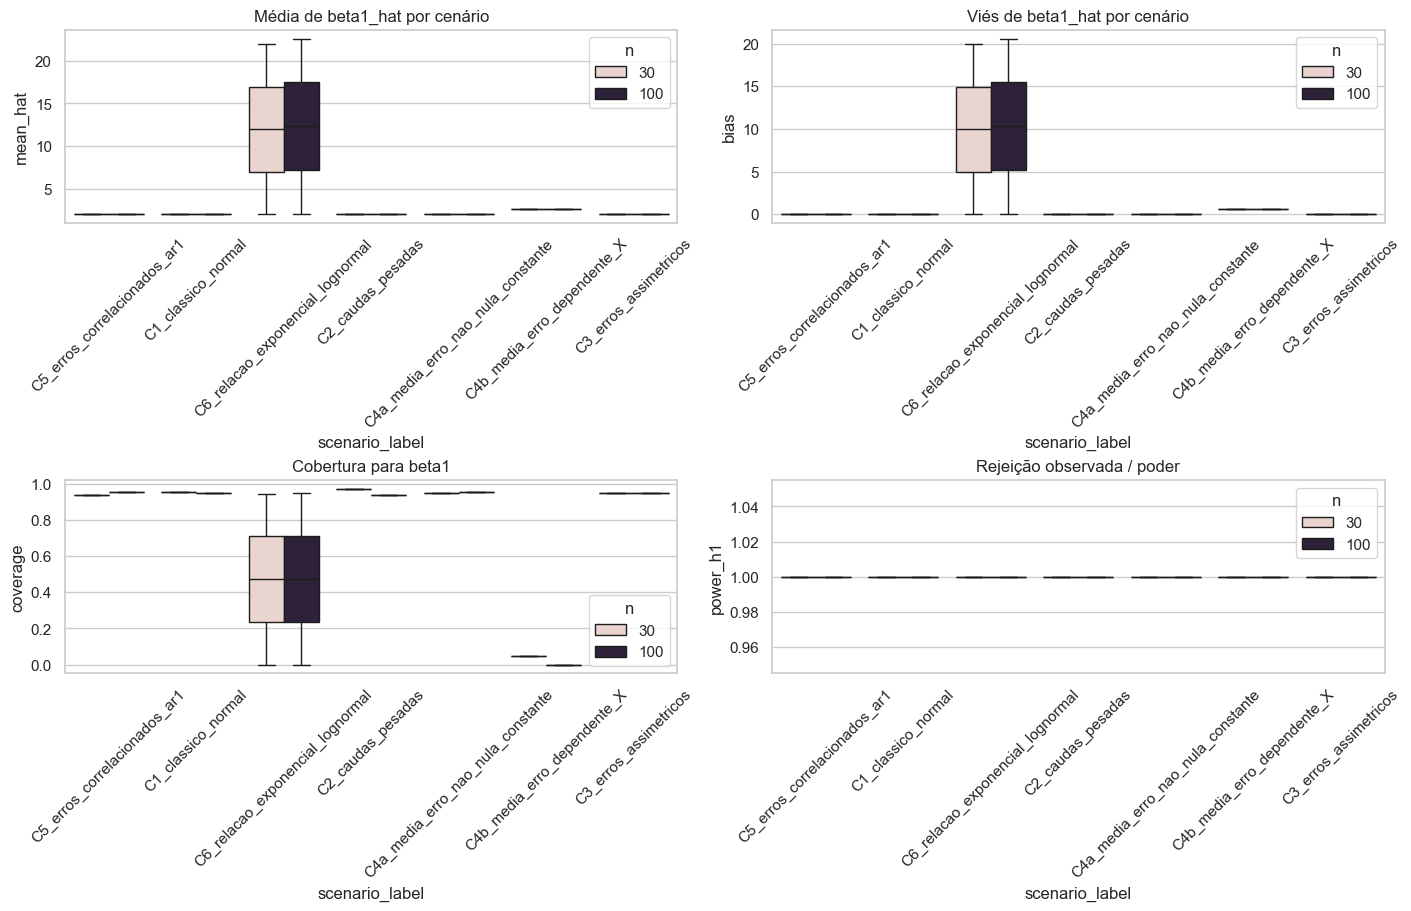

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
plot_data = summary_table[summary_table['parameter'] == 'beta1']

sns.boxplot(data=plot_data, x='scenario_label', y='mean_hat', hue='n', ax=axes[0, 0])
axes[0, 0].set_title('Média de beta1_hat por cenário')
axes[0, 0].tick_params(axis='x', rotation=45)

sns.boxplot(data=plot_data, x='scenario_label', y='bias', hue='n', ax=axes[0, 1])
axes[0, 1].set_title('Viés de beta1_hat por cenário')
axes[0, 1].tick_params(axis='x', rotation=45)

sns.boxplot(data=plot_data, x='scenario_label', y='coverage', hue='n', ax=axes[1, 0])
axes[1, 0].set_title('Cobertura para beta1')
axes[1, 0].tick_params(axis='x', rotation=45)

sns.boxplot(data=plot_data, x='scenario_label', y='power_h1', hue='n', ax=axes[1, 1])
axes[1, 1].set_title('Rejeição observada / poder')
axes[1, 1].tick_params(axis='x', rotation=45)

for ax in axes.flat:
    ax.legend(title='n')

plt.show()

## Síntese automática

A tabela a seguir resume o cenário com `n = 100` e modelo na escala original, que costuma ser a comparação principal do trabalho.

In [10]:
main_view = summary_table[(summary_table['n'] == 100) & (summary_table['model'] == 'original_scale')]
main_view.sort_values(['scenario_label', 'parameter']).reset_index(drop=True)

,scenario_label,scenario,n,model,parameter,mean_hat,bias,variance,mse,coverage,size_h0,power_h1
0,C1_classico_normal,classic_normal,100,original_scale,beta0,1.003529,0.003529,0.009418,0.009421,0.953,1.0,1.0
1,C1_classico_normal,classic_normal,100,original_scale,beta1,1.996901,-0.003099,0.007404,0.007406,0.951,1.0,1.0
2,C2_caudas_pesadas,heavy_tails,100,original_scale,beta0,1.001622,0.001622,0.009892,0.009884,0.947,1.0,1.0
3,C2_caudas_pesadas,heavy_tails,100,original_scale,beta1,2.002533,0.002533,0.007841,0.007839,0.939,1.0,1.0
4,C3_erros_assimetricos,skewed_errors,100,original_scale,beta0,1.003116,0.003116,0.009066,0.009067,0.955,1.0,1.0
5,C3_erros_assimetricos,skewed_errors,100,original_scale,beta1,2.001534,0.001534,0.008006,0.008001,0.950,1.0,1.0
6,C4a_media_erro_nao_nula_constante,nonzero_mean_const,100,original_scale,beta0,2.003765,1.003765,0.010188,1.017722,0.000,1.0,1.0
7,C4a_media_erro_nao_nula_constante,nonzero_mean_const,100,original_scale,beta1,1.999073,-0.000927,0.007131,0.007124,0.955,1.0,1.0
8,C4b_media_erro_dependente_X,nonzero_mean_x_dep,100,original_scale,beta0,1.005095,0.005095,0.010538,0.010554,0.935,1.0,1.0
9,C4b_media_erro_dependente_X,nonzero_mean_x_dep,100,original_scale,beta1,2.601150,0.601150,0.007625,0.368998,0.000,1.0,1.0


## Diagnóstico e correção

Este ponto não pode ser reconstruído integralmente a partir do CSV anexado, porque faltam os resíduos da amostra representativa.

Se houver figuras salvas em `outputs/figures`, você pode inserir abaixo imagens como:

- resíduos vs ajustados
- QQ-plot
- histogramas e boxplots dos estimadores

Caso contrário, a solução correta é rerodar a simulação usando o código do projeto para regenerar os resíduos e os gráficos diagnósticos.

In [11]:
figures_dir = project_root / 'outputs' / 'figures'
existing_figures = sorted([p.name for p in figures_dir.glob('*.png')]) if figures_dir.exists() else []
existing_figures[:20]

['C1_classico_normal_n100_original_scale_boxplot_beta1.png',
 'C1_classico_normal_n100_original_scale_hist_beta1.png',
 'C1_classico_normal_n100_original_scale_qqplot_residuos.png',
 'C1_classico_normal_n100_original_scale_residuos_vs_ajustados.png',
 'C2_caudas_pesadas_n100_original_scale_boxplot_beta1.png',
 'C2_caudas_pesadas_n100_original_scale_hist_beta1.png',
 'C2_caudas_pesadas_n100_original_scale_qqplot_residuos.png',
 'C2_caudas_pesadas_n100_original_scale_residuos_vs_ajustados.png',
 'C3_erros_assimetricos_n100_original_scale_boxplot_beta1.png',
 'C3_erros_assimetricos_n100_original_scale_hist_beta1.png',
 'C3_erros_assimetricos_n100_original_scale_qqplot_residuos.png',
 'C3_erros_assimetricos_n100_original_scale_residuos_vs_ajustados.png',
 'C4a_media_erro_nao_nula_constante_n100_original_scale_boxplot_beta1.png',
 'C4a_media_erro_nao_nula_constante_n100_original_scale_hist_beta1.png',
 'C4a_media_erro_nao_nula_constante_n100_original_scale_qqplot_residuos.png',
 'C4a_media_

## Conclusão

Com este notebook, você consegue apresentar a etapa 12.4 em formato reproduzível, explorando a base de estimativas já gerada pelo projeto.

Para fechar completamente a parte de diagnóstico, o ideal é usar os dados originais da simulação ou as figuras previamente exportadas.